# Trace and Spectral Gauges Between Silhouettes

This notebook generates `fig:spectral-wasserstein-gauge`.  The usual quadratic Wasserstein distance corresponds to the trace gauge $\gamma(M)=\operatorname{tr}(M)$ on displacement covariance matrices.  The spectral gauge $\gamma(M)=\lambda_{\max}(M)$ instead minimizes the largest projected displacement variance.  We compare the induced couplings between a two-disk source and a heart-shaped target, then render the associated displacement interpolations as saturated KDE images, in the same style as the McCann cat-to-heart interpolation figure.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

from PIL import Image
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter
from scipy.optimize import linprog
import ot

NAME = "spectral-wasserstein-gauge"
out = figure_dir(NAME)
rng = np.random.default_rng(34)
assets = FIGROOT / "assets"

We use farthest-point samples for readable coupling panels, and separate denser plans for the interpolation images.  The $\lambda_{\max}$ plan is computed through the robust formulation restricted to a finite set of directions.  For the density panels we accumulate a denser weighted support of each coupling on a grid and apply a Gaussian KDE with a deliberately small bandwidth: white means zero density, and full color is reached at the 95th percentile to avoid saturation artifacts.  Each density panel is cropped around its own transported shape, while the coupling panels keep the wider shifted geometry.


In [2]:
def foreground_points(path, *, max_candidates=24000):
    img = Image.open(path).convert("RGBA")
    arr = np.asarray(img)
    gray = np.asarray(img.convert("L"), dtype=float)
    alpha = arr[..., 3].astype(float)
    if alpha.max() - alpha.min() > 100 and alpha.min() < 80:
        mask = alpha > 80
    else:
        mask = gray < 238
    yy, xx = np.nonzero(mask)
    pts = np.column_stack([xx, -yy]).astype(float)
    pts += rng.uniform(-0.45, 0.45, size=pts.shape)
    pts -= pts.mean(axis=0, keepdims=True)
    pts /= max(np.linalg.norm(pts, axis=1).max(), 1e-12)
    if len(pts) > max_candidates:
        pts = pts[rng.choice(len(pts), size=max_candidates, replace=False)]
    return pts


def farthest_point_sample(points, n, *, seed=0):
    pts = np.asarray(points, dtype=float)
    local_rng = np.random.default_rng(seed)
    idx = np.empty(n, dtype=int)
    idx[0] = int(np.argmin(np.sum((pts - pts.mean(axis=0)) ** 2, axis=1)))
    dist2 = np.sum((pts - pts[idx[0]]) ** 2, axis=1)
    for k in range(1, n):
        idx[k] = int(np.argmax(dist2))
        dist2 = np.minimum(dist2, np.sum((pts - pts[idx[k]]) ** 2, axis=1))
    # A tiny deterministic shuffle avoids visible scan-order artifacts in later samples.
    return pts[local_rng.permutation(idx)]


def spectral_plan(xp, yp, *, n_dirs=42):
    n = len(xp)
    a = b = np.full(n, 1.0 / n)
    diff = xp[:, None, :] - yp[None, :, :]
    angles = np.linspace(0, np.pi, n_dirs, endpoint=False)
    dirs = np.column_stack([np.cos(angles), np.sin(angles)])
    proj_costs = np.stack([(diff @ th) ** 2 for th in dirs], axis=0)

    num_p = n * n
    num_vars = num_p + 1
    c = np.zeros(num_vars)
    c[-1] = 1.0

    A_eq = []
    b_eq = []
    for i in range(n):
        row = np.zeros(num_vars)
        row[i * n : (i + 1) * n] = 1
        A_eq.append(row)
        b_eq.append(a[i])
    for j in range(n):
        row = np.zeros(num_vars)
        row[j:num_p:n] = 1
        A_eq.append(row)
        b_eq.append(b[j])

    A_ub = []
    b_ub = []
    for Cth in proj_costs:
        row = np.zeros(num_vars)
        row[:num_p] = Cth.ravel()
        row[-1] = -1
        A_ub.append(row)
        b_ub.append(0.0)

    res = linprog(
        c,
        A_ub=np.array(A_ub),
        b_ub=np.array(b_ub),
        A_eq=np.array(A_eq),
        b_eq=np.array(b_eq),
        bounds=[(0, None)] * num_vars,
        method="highs",
    )
    if not res.success:
        raise RuntimeError(res.message)
    return res.x[:num_p].reshape(n, n)


alpha_candidates = foreground_points(assets / "twodisks.png")
beta_candidates = foreground_points(assets / "heart.jpg")

alpha_full = farthest_point_sample(alpha_candidates, 5600, seed=41)
beta_full = farthest_point_sample(beta_candidates, 5600, seed=43)
# Normalize the two silhouettes to comparable scale and separate them horizontally.
# The offset prevents the two measures from visually overlapping in the coupling panels.
alpha_full = alpha_full @ np.array([[0.88, 0.00], [0.00, 0.88]]).T + np.array([-0.95, 0.00])
beta_full = beta_full @ np.array([[0.84, -0.04], [0.04, 0.84]]).T + np.array([0.95, 0.01])

# Small readable plans for the two coupling panels.
n_plan = 70
x = farthest_point_sample(alpha_full, n_plan, seed=47)
y = farthest_point_sample(beta_full, n_plan, seed=53)
a = b = np.full(n_plan, 1.0 / n_plan)
C_trace = ot.dist(x, y, metric="sqeuclidean")
P_trace = ot.emd(a, b, C_trace, numItermax=500000)

n_spec = 58
xs = farthest_point_sample(alpha_full, n_spec, seed=59)
ys = farthest_point_sample(beta_full, n_spec, seed=61)
P_spec = spectral_plan(xs, ys, n_dirs=42)

# Denser plans used only for the KDE interpolation rows.
n_trace_density = 2200
x_trace_density = farthest_point_sample(alpha_full, n_trace_density, seed=71)
y_trace_density = farthest_point_sample(beta_full, n_trace_density, seed=73)
a_trace_density = b_trace_density = np.full(n_trace_density, 1.0 / n_trace_density)
P_trace_density = ot.emd(
    a_trace_density,
    b_trace_density,
    ot.dist(x_trace_density, y_trace_density, metric="sqeuclidean"),
    numItermax=800000,
)

n_spec_density = 380
x_spec_density = farthest_point_sample(alpha_full, n_spec_density, seed=79)
y_spec_density = farthest_point_sample(beta_full, n_spec_density, seed=83)
P_spec_density = spectral_plan(x_spec_density, y_spec_density, n_dirs=62)

all_points = np.vstack([alpha_full, beta_full])
xlim, ylim = padded_limits(all_points, pad=0.075)
center = all_points.mean(axis=0)
radius = 0.56 * max(xlim[1] - xlim[0], ylim[1] - ylim[0])
image_xlim = (center[0] - radius, center[0] + radius)
image_ylim = (center[1] - radius, center[1] + radius)
times = [0.0, 0.25, 0.5, 0.75, 1.0]


In [3]:
def plan_pairs(P, max_edges=110):
    entries = [(i, j, float(P[i, j])) for i in range(P.shape[0]) for j in range(P.shape[1]) if P[i, j] > 1e-9]
    return sorted(entries, key=lambda z: z[2], reverse=True)[:max_edges]


def decorate(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)


CLOUD_DOT_SIZE = DIRAC_MARKER_SIZE * 0.030


def draw_cloud_layer(ax, *, zorder=1):
    ax.scatter(alpha_full[:, 0], alpha_full[:, 1], s=CLOUD_DOT_SIZE, marker="o", color=RED, edgecolor="none", linewidth=0, zorder=zorder)
    ax.scatter(beta_full[:, 0], beta_full[:, 1], s=CLOUD_DOT_SIZE, marker="o", color=BLUE, edgecolor="none", linewidth=0, zorder=zorder)


def draw_plan(xp, yp, P, filename, color):
    fig, ax = plt.subplots(figsize=(2.45, 2.10))
    draw_cloud_layer(ax, zorder=1)
    draw_transport_segments(ax, xp, yp, plan_pairs(P), color=color, min_width=0.10, max_width=0.88, alpha_scale=0.46, zorder=2)
    decorate(ax)
    save_pdf(fig, out / filename, pad_inches=0.030)
    plt.close(fig)



def interpolation_support(xp, yp, P, t):
    if t == 0.0:
        return alpha_full, np.full(len(alpha_full), 1.0 / len(alpha_full))
    if t == 1.0:
        return beta_full, np.full(len(beta_full), 1.0 / len(beta_full))
    ii, jj = np.nonzero(P > 1e-13)
    weights = P[ii, jj].astype(float)
    weights /= weights.sum()
    points = (1 - t) * xp[ii] + t * yp[jj]
    return points, weights


def weighted_quantile(values, weights, qs):
    values = np.asarray(values, dtype=float)
    if weights is None:
        return np.quantile(values, qs)
    weights = np.asarray(weights, dtype=float)
    if weights.sum() <= 0:
        return np.quantile(values, qs)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order] / weights.sum()
    cdf = np.cumsum(weights)
    return np.interp(qs, cdf, values)


def square_density_limits(points, weights=None, *, q=0.004, pad=0.090, min_side=1.10):
    """Tight square crop around one transported density panel."""
    x0, x1 = weighted_quantile(points[:, 0], weights, [q, 1 - q])
    y0, y1 = weighted_quantile(points[:, 1], weights, [q, 1 - q])
    cx = 0.5 * (x0 + x1)
    cy = 0.5 * (y0 + y1)
    side = max(x1 - x0, y1 - y0, min_side) * (1 + 2 * pad)
    return (cx - side / 2, cx + side / 2), (cy - side / 2, cy + side / 2)


def density_image(points, weights=None, *, bins=360, sigma=2.00, limits=None):
    if limits is None:
        limits = square_density_limits(points, weights)
    H, xedges, yedges = np.histogram2d(
        points[:, 0],
        points[:, 1],
        bins=bins,
        range=limits,
        weights=weights,
    )
    H = gaussian_filter(H.T, sigma=sigma, mode="nearest")
    return H, (xedges[0], xedges[-1], yedges[0], yedges[-1]), limits


def color_density_image(H, color, *, gamma=0.88):
    color = np.asarray(color, dtype=float)
    vals = H[H > 0]
    scale = np.percentile(vals, 95) if len(vals) else 1.0
    v = np.clip(H / max(scale, 1e-12), 0, 1) ** gamma
    return (1 - v[..., None]) * np.ones((*H.shape, 3)) + v[..., None] * color


def draw_density_panel(points, weights, t, filename, *, sigma=2.00):
    limits = square_density_limits(points, weights)
    H, extent, _ = density_image(points, weights, sigma=sigma, limits=limits)
    fig, ax = plt.subplots(figsize=(1.50, 1.50))
    ax.imshow(color_density_image(H, interp_color(t)), extent=extent, origin="lower", interpolation="bicubic")
    ax.set_xlim(*limits[0])
    ax.set_ylim(*limits[1])
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.006)
    plt.close(fig)


def draw_density_strip(prefix, xp, yp, P, *, sigma=2.00):
    panels = []
    for t in times:
        pts, weights = interpolation_support(xp, yp, P, t)
        suffix = f"t{int(round(100*t)):03d}"
        filename = f"{prefix}-density-{suffix}.pdf"
        draw_density_panel(pts, weights, t, filename, sigma=sigma)
        panels.append((t, pts, weights))

    fig, axes = plt.subplots(1, len(times), figsize=(7.50, 1.50))
    for ax, (t, pts, weights) in zip(axes, panels):
        limits = square_density_limits(pts, weights)
        H, extent, _ = density_image(pts, weights, sigma=sigma, limits=limits)
        ax.imshow(color_density_image(H, interp_color(t)), extent=extent, origin="lower", interpolation="bicubic")
        ax.set_xlim(*limits[0])
        ax.set_ylim(*limits[1])
        ax.set_aspect("equal")
        remove_axes(ax)
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.015)
    save_pdf(fig, out / f"{prefix}-geodesic.pdf", pad_inches=0.006)
    plt.close(fig)


def draw_thumbnail():
    thumb_dir = FIGROOT / "thumbnails"
    thumb_dir.mkdir(parents=True, exist_ok=True)
    fig = plt.figure(figsize=(6.4, 3.55))
    gs = fig.add_gridspec(3, 5, height_ratios=[1.18, 0.86, 0.86], hspace=0.04, wspace=0.025)

    ax = fig.add_subplot(gs[0, 0:2])
    draw_plan_on_ax(ax, x, y, P_trace, VIOLET)
    ax = fig.add_subplot(gs[0, 3:5])
    draw_plan_on_ax(ax, xs, ys, P_spec, ORANGE)

    for row, (xp, yp, P, sigma) in enumerate([
        (x_trace_density, y_trace_density, P_trace_density, 1.60),
        (x_spec_density, y_spec_density, P_spec_density, 3.20),
    ], start=1):
        for col, t in enumerate(times):
            ax = fig.add_subplot(gs[row, col])
            pts, weights = interpolation_support(xp, yp, P, t)
            limits = square_density_limits(pts, weights)
            H, extent, _ = density_image(pts, weights, bins=240, sigma=sigma, limits=limits)
            ax.imshow(color_density_image(H, interp_color(t)), extent=extent, origin="lower", interpolation="bicubic")
            ax.set_xlim(*limits[0])
            ax.set_ylim(*limits[1])
            ax.set_aspect("equal")
            remove_axes(ax)
    fig.savefig(thumb_dir / f"{NAME}.png", dpi=180, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

def draw_plan_on_ax(ax, xp, yp, P, color):
    draw_cloud_layer(ax, zorder=1)
    draw_transport_segments(ax, xp, yp, plan_pairs(P, max_edges=90), color=color, min_width=0.08, max_width=0.74, alpha_scale=0.44, zorder=2)
    decorate(ax)


draw_plan(x, y, P_trace, "trace-coupling.pdf", VIOLET)
draw_plan(xs, ys, P_spec, "lambda-max-coupling.pdf", ORANGE)
draw_density_strip("trace", x_trace_density, y_trace_density, P_trace_density, sigma=1.65)
draw_density_strip("lambda-max", x_spec_density, y_spec_density, P_spec_density, sigma=3.20)
draw_thumbnail()


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


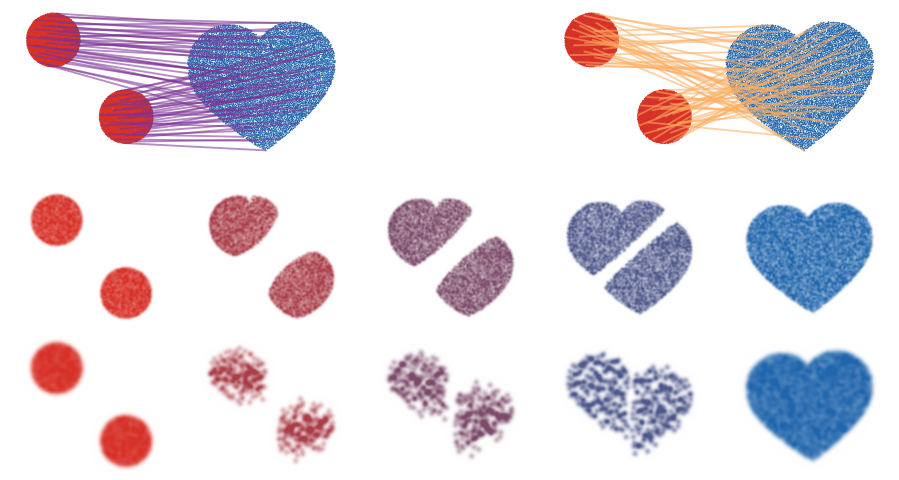

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/spectral-wasserstein-gauge.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/spectral-wasserstein-gauge.png")
display(Image(filename=str(_thumb)))
